# 05 — Analisi Strutturale della Rete Normativa

Questo notebook analizza la struttura della rete normativa del grafo focale e verifica se la gerarchia delle fonti (framework Lamfalussy) è riflessa nella topologia della rete di citazioni.

## Nota metodologica sul framework

Il framework Lamfalussy originale (2001) articola la produzione normativa in **4 livelli**: legge quadro (L1), misure tecniche di attuazione (L2), cooperazione tra autorità di vigilanza (L3), enforcement (L4). Il livello **G1** utilizzato in questo progetto è un'estensione per includere il diritto primario UE (Trattati), che nel Lamfalussy originale è il presupposto implicito — non un livello della piramide settoriale. Ai fini della verifica delle ipotesi strutturali, **G2 è il livello apicale atteso**, coerentemente con il Level 1 del framework originale.

## Ipotesi di ricerca

Se la struttura normativa è razionale e coerente con il framework Lamfalussy, ci aspettiamo:

| # | Ipotesi | Razionale |
|---|---|---|
| H1 | **indegree G2 > indegree G3** | Le leggi quadro (L1) sono più citate dei regolamenti tecnici (L2) |
| H2 | **betweenness G2 > betweenness G3** | Le leggi quadro sono i nodi ponte della rete |
| H3 | **outdegree G5 ≈ 0** | Le sentenze/decisioni sanzionatorie non citano atti normativi |
| H4 | **betweenness atti ibridi > atti puri** | Gli atti che mescolano più livelli occupano posizioni strutturali di confine |

## Input/Output
- **Input**: file esportato da Gephi con metriche calcolate (`gephi_nodes_exported.csv`)
- **Output**: `data/output/{materia}/figures/` + `network_analysis_report.csv`

> **Replicabilità**: questo notebook non contiene parametri specifici per materia. Cambiare `INPUT_FILE` per analizzare un corpus diverso.

## 0. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import sys

sys.path.append('..')
from config_golden_power import MATERIA_NAME

output_path = os.path.join('..', 'data', 'output', MATERIA_NAME)
INPUT_FILE  = os.path.join(output_path, 'gephi_nodes_exported.csv')
OUTPUT_CSV  = os.path.join(output_path, 'network_analysis_report.csv')
OUTPUT_FIGS = os.path.join(output_path, 'figures')
os.makedirs(OUTPUT_FIGS, exist_ok=True)

# Palette layer — coerente con i colori Gephi
LAYER_COLORS = {'G1': '#8B5CF6', 'G2': '#10B981', 'G3': '#F59E0B', 'G4': '#E879F9', 'G5': '#EF4444'}
LAYER_ORDER  = ['G1', 'G2', 'G3', 'G4', 'G5']

# Soglia purezza per definire atti ibridi vs puri
PURITY_THRESHOLD = 0.7

df = pd.read_csv(INPUT_FILE)

# Normalizza nomi colonne Gephi (possono variare leggermente tra versioni)
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]

print(f"Nodi caricati: {len(df)}")
print(f"Colonne: {df.columns.tolist()}")
print()
print("Distribuzione layer:")
print(df['layer'].value_counts().to_string())

Nodi caricati: 3311
Colonne: ['id', 'label', 'year', 'legaltype', 'era', 'decade', 'preamble', 'title', 'layer', 'layer_confidence', 'g1', 'g2', 'g3', 'g4', 'g5', 'motivation', 'layer_entropy', 'pageranks', 'modularity_class', 'indegree', 'outdegree', 'degree', 'closnesscentrality', 'betweenesscentrality', 'clustering']

Distribuzione layer:
layer
G2    1822
G3    1228
G5     218
G4      37
G1       6


## 1. Statistiche Descrittive per Layer

In [3]:
METRICS = ['indegree', 'outdegree', 'degree', 'betweenesscentrality',
           'closnesscentrality', 'clustering']

# Usa solo le metriche effettivamente presenti nel CSV esportato da Gephi
METRICS = [m for m in METRICS if m in df.columns]

stats = df.groupby('layer')[METRICS].agg(['mean', 'median', 'std', 'max'])
stats.columns = ['_'.join(c) for c in stats.columns]
stats = stats.loc[[l for l in LAYER_ORDER if l in stats.index]]

print("=== STATISTICHE PER LAYER ===")
print()

for metric in ['indegree', 'outdegree', 'betweenesscentrality']:
    if metric not in METRICS:
        continue
    print(f"{metric}:")
    for layer in LAYER_ORDER:
        if layer not in df['layer'].values:
            continue
        m   = stats.loc[layer, f'{metric}_mean']
        med = stats.loc[layer, f'{metric}_median']
        mx  = stats.loc[layer, f'{metric}_max']
        n   = (df['layer'] == layer).sum()
        print(f"  {layer} (n={n:>4})  media={m:>8.2f}  mediana={med:>8.2f}  max={mx:>8.2f}")
    print()

=== STATISTICHE PER LAYER ===

indegree:
  G1 (n=   6)  media=    2.67  mediana=    1.00  max=   12.00
  G2 (n=1822)  media=    5.80  mediana=    1.00  max=  274.00
  G3 (n=1228)  media=    1.76  mediana=    1.00  max=   66.00
  G4 (n=  37)  media=    0.97  mediana=    1.00  max=    4.00
  G5 (n= 218)  media=    1.94  mediana=    1.00  max=   26.00

outdegree:
  G1 (n=   6)  media=    0.67  mediana=    1.00  max=    1.00
  G2 (n=1822)  media=    4.63  mediana=    2.00  max=   48.00
  G3 (n=1228)  media=    3.41  mediana=    3.00  max=   43.00
  G4 (n=  37)  media=    1.70  mediana=    0.00  max=   14.00
  G5 (n= 218)  media=    2.43  mediana=    0.00  max=   37.00

betweenesscentrality:
  G1 (n=   6)  media=    0.33  mediana=    0.00  max=    2.00
  G2 (n=1822)  media=  478.57  mediana=    0.00  max=36745.03
  G3 (n=1228)  media=   40.02  mediana=    0.00  max= 6232.38
  G4 (n=  37)  media=   22.26  mediana=    0.00  max=  448.98
  G5 (n= 218)  media=    1.94  mediana=    0.00  max=   

## 2. Verifica delle Ipotesi

Le ipotesi sono formulate con **G2 come livello apicale** della gerarchia normativa settoriale, coerentemente con il Level 1 del framework Lamfalussy originale. G1 (Trattati) è un'estensione del framework e non partecipa alla verifica strutturale principale.

In [4]:
def check_hypothesis(label, condition, value, expected, note=None):
    status = 'CONFERMATA   ' if condition else 'NON CONFERMATA'
    print(f"  [{status}] {label}")
    print(f"               Osservato: {value}  |  Atteso: {expected}")
    if note:
        print(f"               Nota: {note}")
    print()

means     = df.groupby('layer')['indegree'].mean()
means_out = df.groupby('layer')['outdegree'].mean()
means_btw = df.groupby('layer')['betweenesscentrality'].mean()

print("=== VERIFICA IPOTESI ===")
print()

# H1: indegree G2 > G3
check_hypothesis(
    "H1: indegree G2 > G3 (leggi quadro più citate dei regolamenti tecnici)",
    means.get('G2', 0) > means.get('G3', 0),
    f"G2={means.get('G2',0):.2f}, G3={means.get('G3',0):.2f}",
    "G2 > G3"
)

# H2: betweenness G2 > G3
check_hypothesis(
    "H2: betweenness G2 > G3 (leggi quadro sono nodi ponte)",
    means_btw.get('G2', 0) > means_btw.get('G3', 0),
    f"G2={means_btw.get('G2',0):.1f}, G3={means_btw.get('G3',0):.1f}",
    "G2 > G3"
)

# H3: outdegree G5 ≈ 0
g5_out = means_out.get('G5', 0)
check_hypothesis(
    "H3: outdegree G5 ≈ 0 (sentenze non citano atti normativi)",
    g5_out < 1.0,
    f"G5={g5_out:.2f}",
    "< 1.0",
    note="Valori > 0 indicano decisioni di enforcement ibride G3/G5 nel corpus"
)

# H4: betweenness atti ibridi > atti puri
if 'layer_confidence' in df.columns:
    hybrid = df[df['layer_confidence'] <  PURITY_THRESHOLD]
    pure   = df[df['layer_confidence'] >= PURITY_THRESHOLD]
    btw_hybrid = hybrid['betweenesscentrality'].mean()
    btw_pure   = pure['betweenesscentrality'].mean()
    check_hypothesis(
        f"H4: betweenness atti ibridi (purezza<{PURITY_THRESHOLD}) > atti puri",
        btw_hybrid > btw_pure,
        f"ibridi={btw_hybrid:.1f}, puri={btw_pure:.1f}",
        "ibridi > puri",
        note="Gli atti ibridi occupano posizioni di confine tra sottografi normativi"
    )
else:
    print("  [SKIP] H4: colonna layer_confidence non trovata nel CSV")
    print()

=== VERIFICA IPOTESI ===

  [CONFERMATA   ] H1: indegree G2 > G3 (leggi quadro più citate dei regolamenti tecnici)
               Osservato: G2=5.80, G3=1.76  |  Atteso: G2 > G3

  [CONFERMATA   ] H2: betweenness G2 > G3 (leggi quadro sono nodi ponte)
               Osservato: G2=478.6, G3=40.0  |  Atteso: G2 > G3

  [NON CONFERMATA] H3: outdegree G5 ≈ 0 (sentenze non citano atti normativi)
               Osservato: G5=2.43  |  Atteso: < 1.0
               Nota: Valori > 0 indicano decisioni di enforcement ibride G3/G5 nel corpus

  [NON CONFERMATA] H4: betweenness atti ibridi (purezza<0.7) > atti puri
               Osservato: ibridi=161.6, puri=339.4  |  Atteso: ibridi > puri
               Nota: Gli atti ibridi occupano posizioni di confine tra sottografi normativi



## 3. Distribuzione Indegree e Outdegree per Layer

C:\Users\claud\AppData\Local\Temp\ipykernel_23232\1915985636.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_layer, labels=labels_present, patch_artist=True,
C:\Users\claud\AppData\Local\Temp\ipykernel_23232\1915985636.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_layer, labels=labels_present, patch_artist=True,


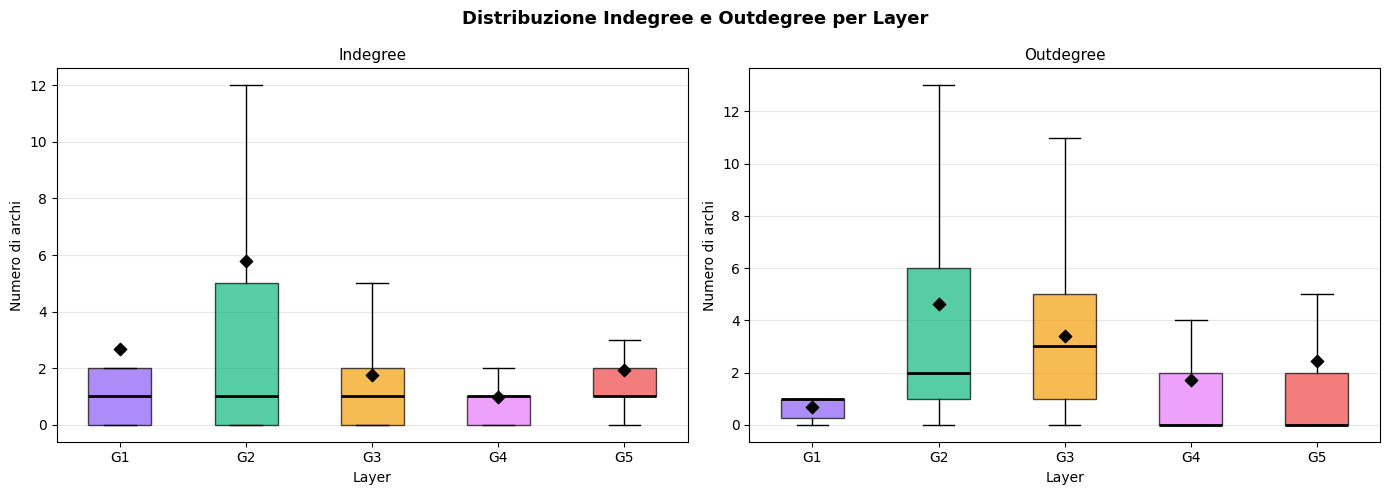

Salvato: fig_degree_distribution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuzione Indegree e Outdegree per Layer', fontsize=13, fontweight='bold')

for ax, metric, label in zip(axes, ['indegree', 'outdegree'], ['Indegree', 'Outdegree']):
    data_by_layer  = [df[df['layer'] == l][metric].values for l in LAYER_ORDER if l in df['layer'].values]
    labels_present = [l for l in LAYER_ORDER if l in df['layer'].values]
    colors_present = [LAYER_COLORS[l] for l in labels_present]

    bp = ax.boxplot(data_by_layer, labels=labels_present, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    showfliers=False)

    for patch, color in zip(bp['boxes'], colors_present):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for i, d in enumerate(data_by_layer):
        ax.scatter(i + 1, np.mean(d), color='black', zorder=5, s=40, marker='D')

    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Layer')
    ax.set_ylabel('Numero di archi')
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FIGS, 'fig_degree_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Salvato: fig_degree_distribution.png")

## 4. Betweenness Centrality per Layer

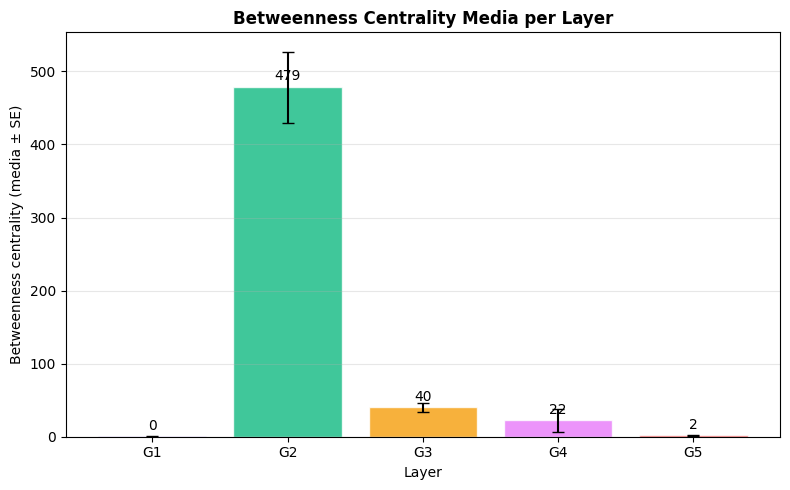

Salvato: fig_betweenness_by_layer.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

layer_means = df.groupby('layer')['betweenesscentrality'].mean().reindex(LAYER_ORDER).dropna()
layer_se    = df.groupby('layer')['betweenesscentrality'].sem().reindex(LAYER_ORDER).dropna()

bars = ax.bar(
    layer_means.index,
    layer_means.values,
    yerr=layer_se.values,
    color=[LAYER_COLORS[l] for l in layer_means.index],
    alpha=0.8,
    capsize=4,
    edgecolor='white'
)

ax.set_title('Betweenness Centrality Media per Layer', fontsize=12, fontweight='bold')
ax.set_xlabel('Layer')
ax.set_ylabel('Betweenness centrality (media ± SE)')
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, layer_means.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FIGS, 'fig_betweenness_by_layer.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Salvato: fig_betweenness_by_layer.png")

## 5. Top Nodi per Indegree

TOP 15 NODI PER INDEGREE

  G2 (0.80 ) | in=274  out=  1  btw=       0 | REGULATION (EU) No 182/2011 OF THE EUROPEAN PARLIAMENT AND OF THE COUNCIL of 16 
  G2 (0.70 ) | in=238  out=  8  btw=   13436 | REGULATION (EU) 2016/679 OF THE EUROPEAN PARLIAMENT AND OF THE COUNCIL of 27 Apr
  G2 (0.60 ) | in=207  out=  9  btw=   36745 | Regulation (EU) 2018/1725 of the European Parliament and of the Council of 23 Oc
  G2 (0.80 ) | in=149  out=  9  btw=    1519 | REGULATION (EU) No 1095/2010 OF THE EUROPEAN PARLIAMENT AND OF THE COUNCIL of 24
  G2 (0.80 ) | in=144  out= 16  btw=    6042 | REGULATION (EU) No 575/2013 OF THE EUROPEAN PARLIAMENT AND OF THE COUNCIL of 26 
  G2 (0.70 ) | in=123  out=  6  btw=     752 | REGULATION (EU) No 1093/2010 OF THE EUROPEAN PARLIAMENT AND OF THE COUNCIL of 24
  G2 (0.70 ) | in=122  out=  0  btw=       0 | Regulation (EU, Euratom) 2018/1046 of the European Parliament and of the Council
  G2 (0.70 ) | in=114  out= 20  btw=   10511 | DIRECTIVE (EU) 2015/849 OF THE 

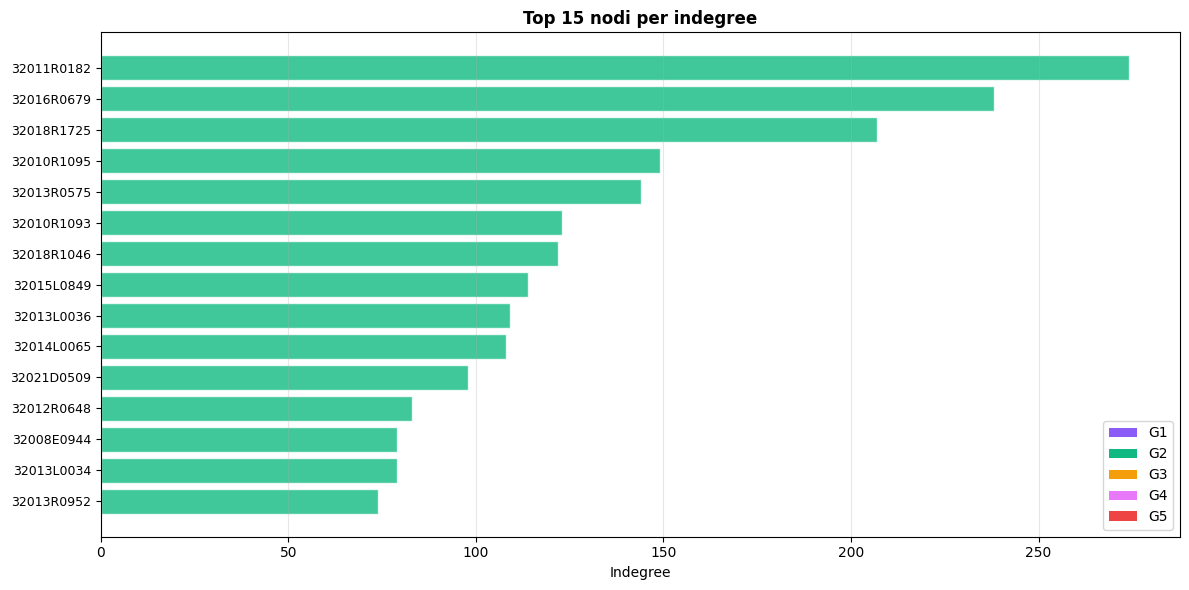

Salvato: fig_top_nodes_indegree.png


In [7]:
N_TOP = 15

top_cols = ['label', 'layer', 'layer_confidence', 'indegree', 'outdegree', 'betweenesscentrality', 'title']
top_cols = [c for c in top_cols if c in df.columns]
top_nodes = df.nlargest(N_TOP, 'indegree')[top_cols].copy()

print(f"TOP {N_TOP} NODI PER INDEGREE")
print()
for _, r in top_nodes.iterrows():
    conf = f"{r['layer_confidence']:<5.2f}" if 'layer_confidence' in r and pd.notna(r['layer_confidence']) else 'N/A  '
    title_str = str(r.get('title', r.get('label', '')))[:80]
    print(f"  {r['layer']} ({conf}) | "
          f"in={r['indegree']:>3}  out={r['outdegree']:>3}  "
          f"btw={r['betweenesscentrality']:>8.0f} | "
          f"{title_str}")

# Grafico
fig, ax = plt.subplots(figsize=(12, 6))
colors = [LAYER_COLORS.get(l, '#999') for l in top_nodes['layer']]
y_pos  = range(len(top_nodes))

ax.barh(list(y_pos), top_nodes['indegree'].values, color=colors, alpha=0.8, edgecolor='white')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(top_nodes['label'].values, fontsize=9)
ax.set_xlabel('Indegree')
ax.set_title(f'Top {N_TOP} nodi per indegree', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=LAYER_COLORS[l], label=l) for l in LAYER_ORDER]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FIGS, 'fig_top_nodes_indegree.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Salvato: fig_top_nodes_indegree.png")

## 6. Ratio Indegree/Outdegree per Layer

Un ratio > 1 indica che il nodo riceve più citazioni di quante ne produce — caratteristica attesa per G2 (Level 1 Lamfalussy). Un ratio < 1 indica il contrario — caratteristica attesa per G3.

In [8]:
df['in_out_ratio'] = df.apply(
    lambda r: r['indegree'] / r['outdegree'] if r['outdegree'] > 0
         else (float('inf') if r['indegree'] > 0 else None),
    axis=1
)

print("Ratio indegree/outdegree per layer (mediana, esclusi nodi con outdegree=0):")
ratio_stats = df[df['outdegree'] > 0].groupby('layer')['in_out_ratio'].agg(['median', 'mean'])
print(ratio_stats.reindex(LAYER_ORDER).dropna().round(2).to_string())
print()

print("% nodi con indegree > outdegree per layer:")
for layer in LAYER_ORDER:
    sub = df[df['layer'] == layer]
    if len(sub) == 0:
        continue
    pct = (sub['indegree'] > sub['outdegree']).sum() / len(sub) * 100
    print(f"  {layer}: {pct:.1f}%  (n={len(sub)})")

Ratio indegree/outdegree per layer (mediana, esclusi nodi con outdegree=0):
       median  mean
layer              
G1       1.00  3.50
G2       0.22  1.74
G3       0.00  0.53
G4       0.07  0.19
G5       0.00  0.36

% nodi con indegree > outdegree per layer:
  G1: 50.0%  (n=6)
  G2: 31.6%  (n=1822)
  G3: 21.6%  (n=1228)
  G4: 37.8%  (n=37)
  G5: 61.5%  (n=218)


## 7. Evoluzione Temporale per Layer

Quanti atti per layer sono stati prodotti in ciascuna decade — mostra come la struttura normativa della materia si è evoluta nel tempo.

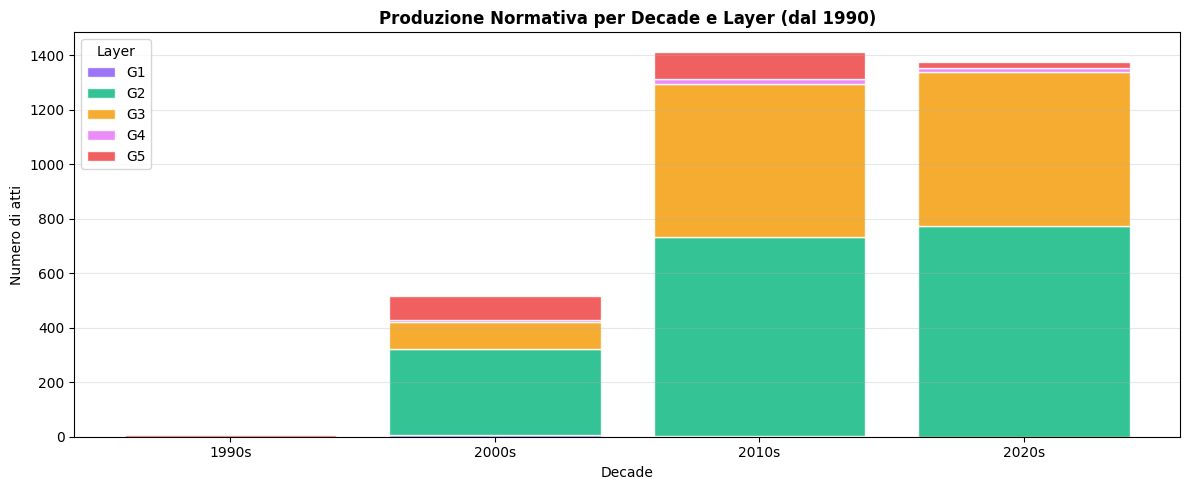

Salvato: fig_temporal_by_layer.png


In [9]:
year_col = 'year' if 'year' in df.columns else 'Year'
temporal = df[df[year_col].notna() & df['layer'].notna()].copy()
temporal['decade'] = (temporal[year_col] // 10 * 10).astype(int)

pivot = temporal.groupby(['decade', 'layer']).size().unstack(fill_value=0)
pivot = pivot[[l for l in LAYER_ORDER if l in pivot.columns]]
pivot = pivot[pivot.index >= 1990]

fig, ax = plt.subplots(figsize=(12, 5))

bottom = np.zeros(len(pivot))
for layer in pivot.columns:
    values = pivot[layer].values
    ax.bar(pivot.index, values, bottom=bottom, label=layer,
           color=LAYER_COLORS[layer], alpha=0.85, width=8, edgecolor='white')
    bottom += values

ax.set_title('Produzione Normativa per Decade e Layer (dal 1990)', fontsize=12, fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('Numero di atti')
ax.set_xticks(pivot.index)
ax.set_xticklabels([f"{d}s" for d in pivot.index])
ax.legend(title='Layer', loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FIGS, 'fig_temporal_by_layer.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Salvato: fig_temporal_by_layer.png")

## 8. Scatter: Purezza Lamfalussy vs Betweenness Centrality

Questo grafico mette in relazione la purezza di classificazione (quanto l'atto è mono-livello) con la centralità strutturale nella rete. Gli atti in alto a sinistra sono strutturalmente centrali MA normativamente ibridi — la posizione più critica secondo il framework Lamfalussy.

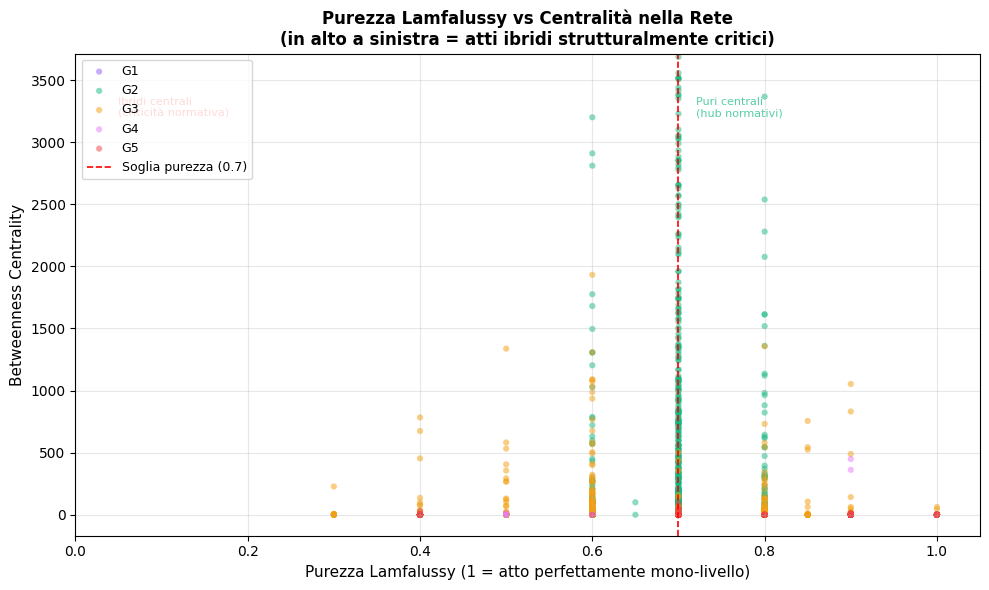

Salvato: fig_purity_vs_betweenness.png

Top 10 atti ibridi per betweenness (purezza < 0.7):
  G2 | purezza=0.60 | btw=36745 | 32018R1725
  G2 | purezza=0.60 | btw=23567 | 32013D0488
  G2 | purezza=0.60 | btw=22340 | 32013R0517
  G2 | purezza=0.60 | btw=15694 | 32021D0509
  G2 | purezza=0.60 | btw=8601 | 32015L1535
  G2 | purezza=0.60 | btw=6884 | 32021R0821
  G3 | purezza=0.50 | btw=6232 | 32019R0317
  G2 | purezza=0.65 | btw=5366 | 32012R1025
  G2 | purezza=0.60 | btw=3200 | 32020R2092
  G2 | purezza=0.60 | btw=2910 | 32014R0651


In [10]:
if 'layer_confidence' not in df.columns:
    print("Colonna layer_confidence non trovata — cella saltata")
else:
    classified = df[df['layer'].notna() & df['layer_confidence'].notna()].copy()

    fig, ax = plt.subplots(figsize=(10, 6))

    for layer in LAYER_ORDER:
        sub = classified[classified['layer'] == layer]
        if len(sub) == 0:
            continue
        ax.scatter(
            sub['layer_confidence'],
            sub['betweenesscentrality'],
            c=LAYER_COLORS[layer],
            label=layer,
            alpha=0.5,
            s=20,
            edgecolors='none'
        )

    # Linea soglia purezza
    ax.axvline(x=PURITY_THRESHOLD, color='red', linestyle='--', linewidth=1.2,
               label=f'Soglia purezza ({PURITY_THRESHOLD})')

    # Etichetta quadranti
    y_max = classified['betweenesscentrality'].quantile(0.98)
    ax.set_ylim(-y_max * 0.05, y_max * 1.1)
    ax.text(0.05, y_max * 0.95, 'Ibridi centrali\n(criticità normativa)',
            fontsize=8, color='red', alpha=0.7)
    ax.text(PURITY_THRESHOLD + 0.02, y_max * 0.95, 'Puri centrali\n(hub normativi)',
            fontsize=8, color='#10B981', alpha=0.7)

    ax.set_xlabel('Purezza Lamfalussy (1 = atto perfettamente mono-livello)', fontsize=11)
    ax.set_ylabel('Betweenness Centrality', fontsize=11)
    ax.set_title('Purezza Lamfalussy vs Centralità nella Rete\n'
                 '(in alto a sinistra = atti ibridi strutturalmente critici)',
                 fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1.05)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FIGS, 'fig_purity_vs_betweenness.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Salvato: fig_purity_vs_betweenness.png")

    # Stampa i top 10 atti ibridi per betweenness
    print()
    print("Top 10 atti ibridi per betweenness (purezza < 0.7):")
    ibridi = classified[classified['layer_confidence'] < PURITY_THRESHOLD]
    label_col = 'label' if 'label' in ibridi.columns else 'Label'
    top_ibridi = ibridi.nlargest(10, 'betweenesscentrality')[
        [label_col, 'layer', 'layer_confidence', 'betweenesscentrality']
    ]
    for _, r in top_ibridi.iterrows():
        print(f"  {r['layer']} | purezza={r['layer_confidence']:.2f} | "
              f"btw={r['betweenesscentrality']:.0f} | {r[label_col]}")

## 9. Export Report

In [ ]:
agg_dict = {
    'n_nodes':           ('id', 'count'),
    'indegree_mean':     ('indegree', 'mean'),
    'indegree_median':   ('indegree', 'median'),
    'indegree_max':      ('indegree', 'max'),
    'outdegree_mean':    ('outdegree', 'mean'),
    'outdegree_median':  ('outdegree', 'median'),
    'betweenness_mean':  ('betweenesscentrality', 'mean'),
    'betweenness_max':   ('betweenesscentrality', 'max'),
}

if 'clustering' in df.columns:
    agg_dict['clustering_mean'] = ('clustering', 'mean')

if 'layer_confidence' in df.columns:
    agg_dict['pct_pure'] = ('layer_confidence', lambda x: (x >= PURITY_THRESHOLD).sum() / len(x) * 100)
    agg_dict['purity_mean'] = ('layer_confidence', 'mean')

report = df.groupby('layer').agg(**agg_dict).reindex(LAYER_ORDER).round(2)

report.to_csv(OUTPUT_CSV)

print(f"Report salvato: {OUTPUT_CSV}")
print()
print("=" * 60)
print("RIEPILOGO ANALISI STRUTTURALE")
print("=" * 60)
print(report.to_string())
print()

figs = ['fig_degree_distribution.png', 'fig_betweenness_by_layer.png',
        'fig_top_nodes_indegree.png', 'fig_temporal_by_layer.png',
        'fig_purity_vs_betweenness.png']
print("Figure:")
for fig_name in figs:
    path   = os.path.join(OUTPUT_FIGS, fig_name)
    exists = os.path.exists(path)
    print(f"  {'OK     ' if exists else 'MANCANTE'} {fig_name}")